<a href="https://colab.research.google.com/github/GreeshmaDS/gold-price-prediction.ipynb/blob/main/PA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gold (2).csv to Gold (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

df = pd.read_csv("Gold (2).csv")
print(df.head())
print(df.columns)

         Date  Close/Last    Volume    Open    High     Low
0  10/28/2022      1648.3  186519.0  1667.2  1670.9  1640.7
1  10/27/2022      1668.8  180599.0  1668.8  1674.8  1658.5
2  10/26/2022      1669.2  183453.0  1657.7  1679.4  1653.8
3  10/25/2022      1658.0  178706.0  1654.5  1666.8  1641.2
4  10/24/2022      1654.1  167448.0  1662.9  1675.5  1648.0
Index(['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low'], dtype='object')


In [ ]:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

In [ ]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'])

df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_549/2970595833.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)


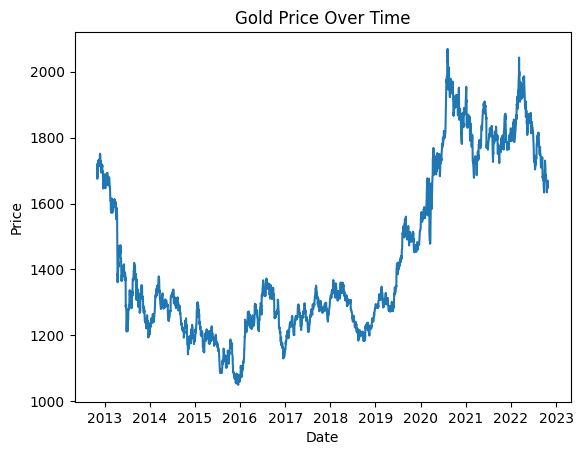

In [ ]:
plt.figure()
plt.plot(df['Date'], df['Close/Last'])
plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
df['Prev_Price'] = df['Close/Last'].shift(1)
df = df.dropna()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Prev_Price']]
y = df['Close/Last']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 10.223140105726392
RMSE: 15.624090845169922
R2 Score: 0.9901988933077395


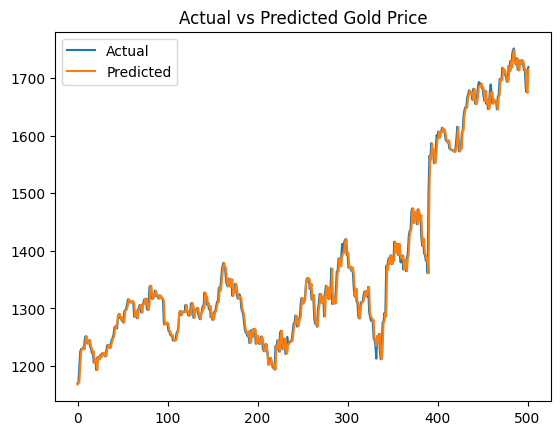

In [ ]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Gold Price")
plt.show()

In [ ]:
data = df[['Close/Last']].values

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [ ]:
import numpy as np

def create_dataset(dataset, time_step=10):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(scaled_data, time_step)

In [ ]:
train_size = int(len(X)*0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0153
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.3789e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.6419e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.4281e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.4847e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.1351e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 8.2585e-04
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.1471e-04
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.7570e-04
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7061e-04


In [ ]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Convert back to original values
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


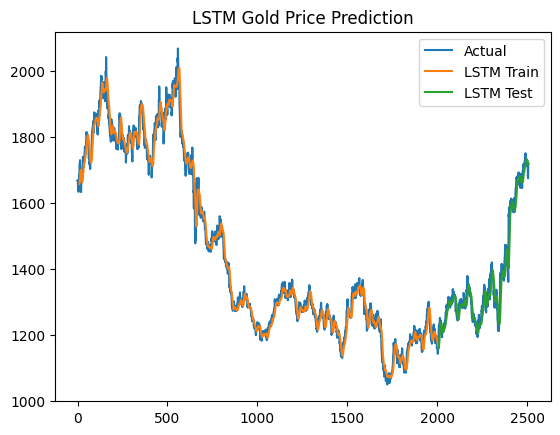

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

# Original data
plt.plot(scaler.inverse_transform(scaled_data), label="Actual")

# Train prediction plot
train_plot = np.empty_like(scaled_data)
train_plot[:] = np.nan
train_plot[time_step:time_step+len(train_pred)] = train_pred

# Test prediction plot (FIXED)
test_plot = np.empty_like(scaled_data)
test_plot[:] = np.nan
test_start = time_step + len(train_pred)
test_plot[test_start:test_start+len(test_pred)] = test_pred

# Plot
plt.plot(train_plot, label="LSTM Train")
plt.plot(test_plot, label="LSTM Test")

plt.legend()
plt.title("LSTM Gold Price Prediction")
plt.show()